**Part 1: Data Preprocessing**

1.1 Import Data and Load

In [2]:
import pandas as pd
import numpy as np
import re
import string

#load
resume_df = pd.read_csv('/content/Resume.csv')
job_df = pd.read_csv('/content/job_title_des.csv')

#glimpse
print("Resume Dataset:")
display(resume_df.head())

print("\nJob Dataset:")
display(job_df.head())

Resume Dataset:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR



Job Dataset:


,Unnamed: 0,Job Title,Job Description
0,0,Flutter Developer,We are looking for hire experts flutter develo...
1,1,Django Developer,PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ ...
2,2,Machine Learning,"Data Scientist (Contractor)\n\nBangalore, IN\n..."
3,3,iOS Developer,JOB DESCRIPTION:\n\nStrong framework outside o...
4,4,Full Stack Developer,job responsibility full stack engineer – react...


1.2 Clean Data

In [3]:
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
print(resume_df.columns)
print(job_df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')
Index(['Unnamed: 0', 'Job Title', 'Job Description'], dtype='object')


In [4]:
resume_text_col = 'Resume_str'
job_text_col = 'Job Description'

resume_df['cleaned_resume'] = resume_df[resume_text_col].apply(clean_text)
job_df['cleaned_job'] = job_df[job_text_col].apply(clean_text)

display(resume_df[['cleaned_resume']].head())
display(job_df[['cleaned_job']].head())

,cleaned_resume
0,hr administratormarketing associate hr adminis...
1,hr specialist us hr operations summary versati...
2,hr director summary over years experience in r...
3,hr specialist summary dedicated driven and dyn...
4,hr manager skill highlights hr skills hr depar...


,cleaned_job
0,we are looking for hire experts flutter develo...
1,pythondjango developerlead job codepdj strong ...
2,data scientist contractor bangalore in respons...
3,job description strong framework outside of io...
4,job responsibility full stack engineer – react...


1.3 Handling Data Quality

In [5]:
#remove empty rows
resume_df = resume_df[resume_df['cleaned_resume'] != ""]
job_df = job_df[job_df['cleaned_job'] != ""]

#drop duplicates
resume_df = resume_df.drop_duplicates(subset=['cleaned_resume'])
job_df = job_df.drop_duplicates(subset=['cleaned_job'])

print("After cleaning:")
print("Resumes:", len(resume_df))
print("Jobs:", len(job_df))

After cleaning:
Resumes: 2481
Jobs: 2251


1.4 Skill Extraction

In [6]:
skills_list = [
    'python', 'java', 'sql', 'machine learning', 'deep learning',
    'data analysis', 'pandas', 'numpy', 'tensorflow', 'pytorch',
    'excel', 'communication', 'leadership'
]

def extract_skills(text):
    found_skills = []
    for skill in skills_list:
        if skill in text:
            found_skills.append(skill)
    return found_skills

resume_df['skills'] = resume_df['cleaned_resume'].apply(extract_skills)

display(resume_df[['cleaned_resume', 'skills']].head())

,cleaned_resume,skills
0,hr administratormarketing associate hr adminis...,"[data analysis, leadership]"
1,hr specialist us hr operations summary versati...,[communication]
2,hr director summary over years experience in r...,"[excel, leadership]"
3,hr specialist summary dedicated driven and dyn...,"[excel, communication]"
4,hr manager skill highlights hr skills hr depar...,"[excel, leadership]"


In [7]:
# Ensure categories and titles are strings to avoid errors during matching
resume_df['Category'] = resume_df['Category'].astype(str)
job_df['Job Title'] = job_df['Job Title'].astype(str)

# Quick check: Do we have overlapping keywords?
print(f"Sample Resume Categories: {resume_df['Category'].unique()[:5]}")
print(f"Sample Job Titles: {job_df['Job Title'].unique()[:5]}")

Sample Resume Categories: ['HR' 'DESIGNER' 'INFORMATION-TECHNOLOGY' 'TEACHER' 'ADVOCATE']
Sample Job Titles: ['Flutter Developer' 'Django Developer' 'Machine Learning' 'iOS Developer'
 'Full Stack Developer']


1.5 Dataset Construction

In [8]:
import random

def construct_dataset(resumes, jobs, num_negatives=3):
    dataset = []

    for _, resume_row in resumes.iterrows():
        # Get the category of the current resume
        category = resume_row['Category'].lower().replace('-', ' ')

        # 1. Find a "Positive" match
        # We look for jobs where the title contains the resume's category name
        positives = jobs[jobs['Job Title'].str.lower().str.contains(category, na=False)]

        if positives.empty:
            # Fallback: if no category match is found, pick a random job (not ideal, but keeps code running)
            positive_job = jobs.sample(1).iloc[0]
        else:
            positive_job = positives.sample(1).iloc[0]

        # 2. Find "Negative" matches (random jobs that aren't the positive one)
        negatives = jobs[~jobs.index.isin([positive_job.name])].sample(num_negatives)

        # 3. Construct the structured sample
        sample = {
            'resume_text': resume_row['cleaned_resume'],
            'resume_id': resume_row['ID'],
            'positive_job': positive_job['cleaned_job'],
            'negative_jobs': negatives['cleaned_job'].tolist(),
            'category': category
        }
        dataset.append(sample)

    return pd.DataFrame(dataset)

# Execute the construction
pairs_df = construct_dataset(resume_df, job_df)
print(f"Dataset constructed with {len(pairs_df)} samples.")

Dataset constructed with 2481 samples.


**Part 2: Baseline Model Building**

2.1 Train/Val/Test Split

In [9]:
from sklearn.model_selection import train_test_split

# 70% Train, 30% for Val+Test
train_df, temp_df = train_test_split(pairs_df, test_size=0.3, random_state=42)

# Split the 30% into 15% Val and 15% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Training set: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

Training set: 1736 | Validation: 372 | Test: 373


2.2 Baseline Model (TF-IDF Similarity)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def evaluate_baseline(df):
    vectorizer = TfidfVectorizer(stop_words='english')
    correct_hits = 0

    for _, row in df.iterrows():
        # The list of jobs to compare: [The Right One, Wrong 1, Wrong 2, Wrong 3]
        candidates = [row['positive_job']] + row['negative_jobs']
        all_texts = [row['resume_text']] + candidates

        # Convert text to numerical vectors
        tfidf_matrix = vectorizer.fit_transform(all_texts)

        # Compare Resume (index 0) against all Job Candidates (index 1 onwards)
        # We calculate "Cosine Similarity" (how close the word vectors are)
        scores = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()

        # If the highest score is at index 0, the model correctly picked the 'Positive' job
        if np.argmax(scores) == 0:
            correct_hits += 1

    return (correct_hits / len(df)) * 100

# Run evaluation
accuracy = evaluate_baseline(val_df)
print(f"Baseline TF-IDF Accuracy: {accuracy:.2f}%")

Baseline TF-IDF Accuracy: 23.92%


**Part 3: Embedding Model Buidling**

3.1 Install and Load Sentence-Transformers

In [11]:
!pip install -U sentence-transformers

from sentence_transformers import SentenceTransformer, util
import torch

# Load a pre-trained model
# 'all-MiniLM-L6-v2' is a great balance of speed and performance
model = SentenceTransformer('all-MiniLM-L6-v2')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.4.0
    Uninstalling sentence-transformers-5.4.0:
      Successfully uninstalled sentence-transformers-5.4.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

3.2 Encode Text into Embeddings

In [12]:
#Precompute Resume Embeddings
val_df['resume_embedding'] = val_df['resume_text'].apply(
    lambda x: model.encode(x, convert_to_tensor=True)
)

print("Resume embeddings computed.")

Resume embeddings computed.


In [13]:
#Precompute Job Embeddings
def encode_jobs(row):
    jobs = [row['positive_job']] + row['negative_jobs']
    return model.encode(jobs, convert_to_tensor=True)

val_df['job_embeddings'] = val_df.apply(encode_jobs, axis=1)

print("Job embeddings computed.")

Job embeddings computed.


In [14]:
#Function to evaluate embedding-based model
def evaluate_embedding_model_fast(df):
    correct_hits = 0

    for _, row in df.iterrows():
        # Compute similarity using precomputed embeddings
        scores = util.cos_sim(row['resume_embedding'], row['job_embeddings'])[0]
        scores = scores.cpu().numpy()

        # Check if highest score corresponds to correct job (index 0)
        if np.argmax(scores) == 0:
            correct_hits += 1

    return (correct_hits / len(df)) * 100

3.3 Run Evaluation

In [15]:
embedding_accuracy = evaluate_embedding_model_fast(val_df)
print(f"Embedding Model Accuracy: {embedding_accuracy:.2f}%")

Embedding Model Accuracy: 26.61%


3.4 Baseline Comparison

In [16]:
print(f"Baseline Accuracy: {accuracy:.2f}%")
print(f"Embedding Accuracy: {embedding_accuracy:.2f}%")

Baseline Accuracy: 23.92%
Embedding Accuracy: 26.61%


**Part 4: Building the Enhanced / Final Model (Hybrid System)**

4.1 TF-IDF Scoring Function

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def compute_tfidf_scores(resume_text, job_texts):
    # Fit TF-IDF on resume + jobs
    vectorizer = TfidfVectorizer(stop_words='english')
    all_texts = [resume_text] + job_texts
    tfidf_matrix = vectorizer.fit_transform(all_texts)

    # Compute similarity
    scores = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
    return scores

4.2 Hybrid Model Evaluation Function

In [18]:
def evaluate_hybrid_model(df, embedding_weight=0.7, tfidf_weight=0.3):
    correct_hits = 0

    for _, row in df.iterrows():
        candidates = [row['positive_job']] + row['negative_jobs']

        # --- Embedding scores (use precomputed) ---
        emb_scores = util.cos_sim(row['resume_embedding'], row['job_embeddings'])[0]
        emb_scores = emb_scores.cpu().numpy()

        # --- TF-IDF scores ---
        tfidf_scores = compute_tfidf_scores(row['resume_text'], candidates)

        # --- Normalize both (important!) ---
        emb_scores = (emb_scores - emb_scores.min()) / (emb_scores.max() - emb_scores.min() + 1e-8)
        tfidf_scores = (tfidf_scores - tfidf_scores.min()) / (tfidf_scores.max() - tfidf_scores.min() + 1e-8)

        # --- Combine ---
        final_scores = embedding_weight * emb_scores + tfidf_weight * tfidf_scores

        # Check if correct job (index 0) is highest
        if np.argmax(final_scores) == 0:
            correct_hits += 1

    return (correct_hits / len(df)) * 100

4.3 Run Hybrid Model

In [19]:
hybrid_accuracy = evaluate_hybrid_model(val_df)

print(f"Hybrid Model Accuracy: {hybrid_accuracy:.2f}%")

Hybrid Model Accuracy: 27.42%


4.4 Compare all Models

In [20]:
print("Model Comparison:")
print(f"Baseline (TF-IDF): {accuracy:.2f}%")
print(f"Embedding Model: {embedding_accuracy:.2f}%")
print(f"Hybrid Model: {hybrid_accuracy:.2f}%")

Model Comparison:
Baseline (TF-IDF): 23.92%
Embedding Model: 26.61%
Hybrid Model: 27.42%


4.5 Hyperparameter Tuning

In [21]:
weights = [0.3, 0.5, 0.7, 0.9]

for w in weights:
    acc = evaluate_hybrid_model(val_df, embedding_weight=w, tfidf_weight=1-w)
    print(f"Embedding Weight: {w:.1f} | Accuracy: {acc:.2f}%")

Embedding Weight: 0.3 | Accuracy: 26.08%
Embedding Weight: 0.5 | Accuracy: 27.15%
Embedding Weight: 0.7 | Accuracy: 27.42%
Embedding Weight: 0.9 | Accuracy: 27.15%


4.6 Ablation Study

In [22]:
best_hybrid_acc = evaluate_hybrid_model(val_df, embedding_weight=0.5, tfidf_weight=0.5)

results = {
    "TF-IDF": accuracy,
    "Embedding": embedding_accuracy,
    "Hybrid (0.5)": best_hybrid_acc
}

for model_name, score in results.items():
    print(f"{model_name}: {score:.2f}%")

TF-IDF: 23.92%
Embedding: 26.61%
Hybrid (0.5): 27.15%


**Part 5: Evaluation Metrics**

5.1 Top-K Accuracy (Ranking Performance)

In [23]:
def evaluate_top_k(df, k=3):
    correct_hits = 0

    for _, row in df.iterrows():
        candidates = [row['positive_job']] + row['negative_jobs']

        emb_scores = util.cos_sim(row['resume_embedding'], row['job_embeddings'])[0].cpu().numpy()
        tfidf_scores = compute_tfidf_scores(row['resume_text'], candidates)

        emb_scores = (emb_scores - emb_scores.min()) / (emb_scores.max() - emb_scores.min() + 1e-8)
        tfidf_scores = (tfidf_scores - tfidf_scores.min()) / (tfidf_scores.max() - tfidf_scores.min() + 1e-8)

        final_scores = 0.5 * emb_scores + 0.5 * tfidf_scores

        top_k = np.argsort(final_scores)[-k:]

        if 0 in top_k:
            correct_hits += 1

    return correct_hits / len(df)
print(f"Top-1 Accuracy (val): {best_hybrid_acc:.2f}%")
print(f"Top-3 Accuracy (val): {evaluate_top_k(val_df, k=3)*100:.2f}%")


Top-1 Accuracy (val): 27.15%
Top-3 Accuracy (val): 76.61%


5.2 Mean Reciprocal Rank (MRR)

In [24]:
def evaluate_mrr(df):
    reciprocal_ranks = []

    for _, row in df.iterrows():
        candidates = [row['positive_job']] + row['negative_jobs']

        emb_scores = util.cos_sim(row['resume_embedding'], row['job_embeddings'])[0].cpu().numpy()
        tfidf_scores = compute_tfidf_scores(row['resume_text'], candidates)

        emb_scores = (emb_scores - emb_scores.min()) / (emb_scores.max() - emb_scores.min() + 1e-8)
        tfidf_scores = (tfidf_scores - tfidf_scores.min()) / (tfidf_scores.max() - tfidf_scores.min() + 1e-8)

        final_scores = 0.5 * emb_scores + 0.5 * tfidf_scores

        ranked_indices = np.argsort(final_scores)[::-1]
        rank_of_correct = np.where(ranked_indices == 0)[0][0] + 1
        reciprocal_ranks.append(1.0 / rank_of_correct)

    return np.mean(reciprocal_ranks)
print(f"MRR (val): {evaluate_mrr(val_df):.4f}")

MRR (val): 0.5370


5.3 Summary of Evaluation Metrics

In [25]:
val_results = pd.DataFrame({
    "Metric": ["Top-1 Accuracy", "Top-3 Accuracy", "MRR"],
    "Value": [
        f"{best_hybrid_acc:.2f}%",
        f"{evaluate_top_k(val_df, k=3)*100:.2f}%",
        f"{evaluate_mrr(val_df):.4f}"
    ]
})

display(val_results)

,Metric,Value
0,Top-1 Accuracy,27.15%
1,Top-3 Accuracy,76.61%
2,MRR,0.5370


**Part 6: Error Analysis**

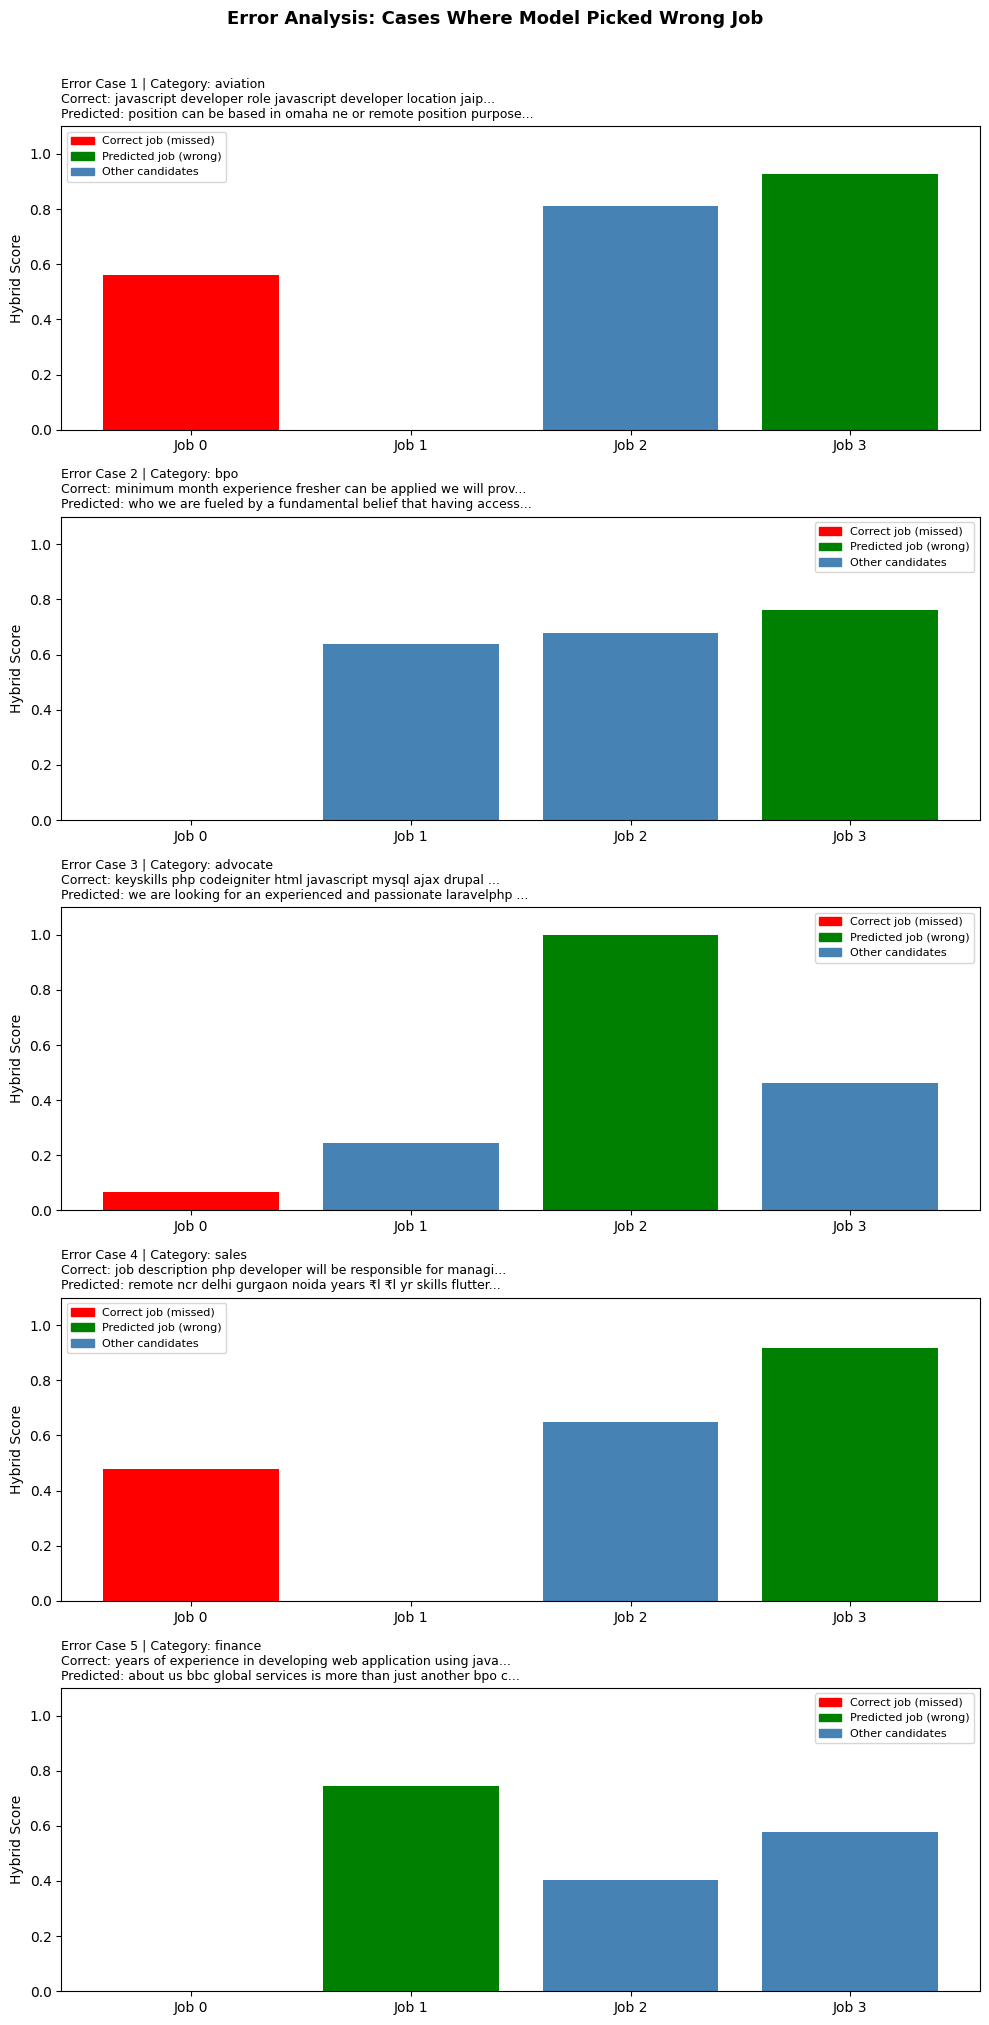

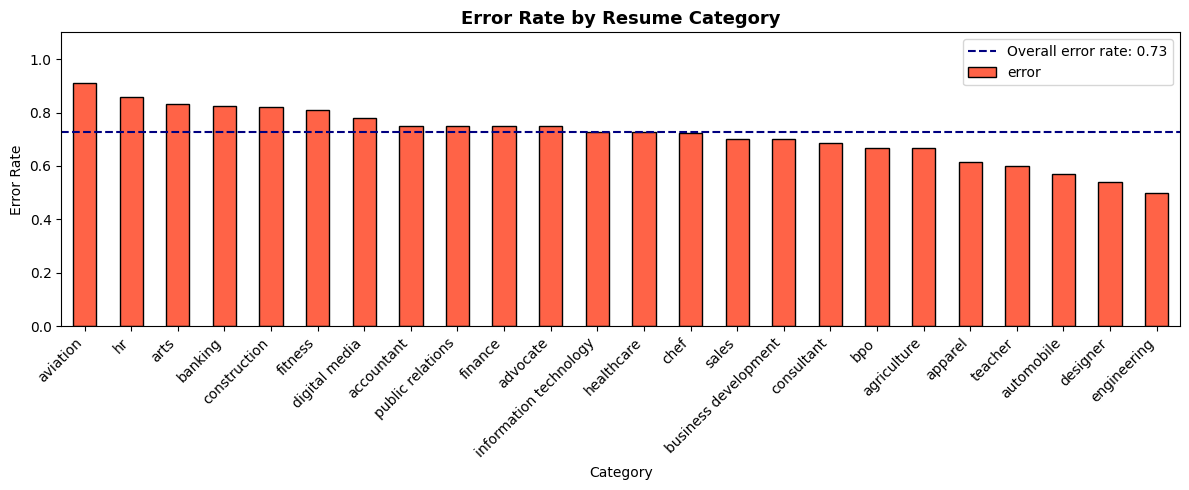


===== ERROR CASE SUMMARIES =====

--- Error Case 1 | Category: aviation ---
Resume:        customer service representative career focus dedicated and skilled cash administrator who excels at prioritizing and completing multiple tasks simultaneously committed to delivering high quality resul
Correct job:   javascript developer role javascript developer location jaipur experience years skills and qualifica
Predicted job: position can be based in omaha ne or remote position purpose this position will consultanalyze and d

--- Error Case 2 | Category: bpo ---
Resume:        general manager and board member executive profile high performing customer relationship management bpo executive with proven experience managing high growthcomplex operations serving diverse industri
Correct job:   minimum month experience fresher can be applied we will provided sty funds for fresher candidate web
Predicted job: who we are fueled by a fundamental belief that having access to financial services creates

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def show_errors(df, n=5):
    count = 0
    error_cases = []

    for _, row in df.iterrows():
        candidates = [row['positive_job']] + row['negative_jobs']

        emb_scores = util.cos_sim(row['resume_embedding'], row['job_embeddings'])[0].cpu().numpy()
        tfidf_scores = compute_tfidf_scores(row['resume_text'], candidates)

        emb_scores = (emb_scores - emb_scores.min()) / (emb_scores.max() - emb_scores.min() + 1e-8)
        tfidf_scores = (tfidf_scores - tfidf_scores.min()) / (tfidf_scores.max() - tfidf_scores.min() + 1e-8)

        final_scores = 0.5 * emb_scores + 0.5 * tfidf_scores
        pred_idx = np.argmax(final_scores)

        if pred_idx != 0:
            error_cases.append({
                'resume': row['resume_text'][:200],
                'correct_job': candidates[0][:100],
                'predicted_job': candidates[pred_idx][:100],
                'final_scores': final_scores,
                'pred_idx': pred_idx,
                'category': row['category']
            })
            count += 1

        if count >= n:
            break

    fig, axes = plt.subplots(n, 1, figsize=(10, 4 * n))
    if n == 1:
        axes = [axes]

    for i, case in enumerate(error_cases):
        ax = axes[i]
        num_candidates = len(case['final_scores'])
        colors = ['red' if j == 0 else ('green' if j == case['pred_idx'] else 'steelblue')
                  for j in range(num_candidates)]
        bars = ax.bar([f"Job {j}" for j in range(num_candidates)],
                      case['final_scores'], color=colors)
        ax.set_title(f"Error Case {i+1} | Category: {case['category']}\n"
                     f"Correct: {case['correct_job'][:60]}...\n"
                     f"Predicted: {case['predicted_job'][:60]}...",
                     fontsize=9, loc='left')
        ax.set_ylabel("Hybrid Score")
        ax.set_ylim(0, 1.1)

        red_patch = mpatches.Patch(color='red', label='Correct job (missed)')
        green_patch = mpatches.Patch(color='green', label='Predicted job (wrong)')
        blue_patch = mpatches.Patch(color='steelblue', label='Other candidates')
        ax.legend(handles=[red_patch, green_patch, blue_patch], fontsize=8)

    plt.suptitle("Error Analysis: Cases Where Model Picked Wrong Job", fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("error_analysis_scores.png", bbox_inches='tight')
    plt.show()

    all_errors = []
    for _, row in df.iterrows():
        candidates = [row['positive_job']] + row['negative_jobs']
        emb_scores = util.cos_sim(row['resume_embedding'], row['job_embeddings'])[0].cpu().numpy()
        tfidf_scores = compute_tfidf_scores(row['resume_text'], candidates)
        emb_scores = (emb_scores - emb_scores.min()) / (emb_scores.max() - emb_scores.min() + 1e-8)
        tfidf_scores = (tfidf_scores - tfidf_scores.min()) / (tfidf_scores.max() - tfidf_scores.min() + 1e-8)
        final_scores = 0.5 * emb_scores + 0.5 * tfidf_scores
        pred_idx = np.argmax(final_scores)
        all_errors.append({'category': row['category'], 'error': int(pred_idx != 0)})

    error_df = pd.DataFrame(all_errors)
    error_rate = error_df.groupby('category')['error'].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    error_rate.plot(kind='bar', ax=ax, color='tomato', edgecolor='black')
    ax.set_title("Error Rate by Resume Category", fontsize=13, fontweight='bold')
    ax.set_xlabel("Category")
    ax.set_ylabel("Error Rate")
    ax.set_ylim(0, 1.1)
    ax.axhline(y=error_df['error'].mean(), color='navy', linestyle='--', label=f"Overall error rate: {error_df['error'].mean():.2f}")
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("error_rate_by_category.png", bbox_inches='tight')
    plt.show()

    print("\n===== ERROR CASE SUMMARIES =====")
    for i, case in enumerate(error_cases):
        print(f"\n--- Error Case {i+1} | Category: {case['category']} ---")
        print(f"Resume:        {case['resume']}")
        print(f"Correct job:   {case['correct_job']}")
        print(f"Predicted job: {case['predicted_job']}")

show_errors(val_df)

**Part 7: Final Evaluation on Test Set**

In [27]:
# Recompute embeddings for test_df
test_df['resume_embedding'] = test_df['resume_text'].apply(
    lambda x: model.encode(x, convert_to_tensor=True)
)

test_df['job_embeddings'] = test_df.apply(
    lambda row: model.encode([row['positive_job']] + row['negative_jobs'], convert_to_tensor=True),
    axis=1
)

# Evaluate best model
test_accuracy = evaluate_hybrid_model(test_df, embedding_weight=0.5, tfidf_weight=0.5)

print(f"Final Test Accuracy: {test_accuracy:.2f}%")
print(f"Top-3 Accuracy (test): {evaluate_top_k(test_df, k=3)*100:.2f}%")
print(f"MRR (test): {evaluate_mrr(test_df):.4f}")

test_results = pd.DataFrame({
    "Metric": ["Top-1 Accuracy", "Top-3 Accuracy", "MRR"],
    "Value": [
        f"{test_accuracy:.2f}%",
        f"{evaluate_top_k(test_df, k=3)*100:.2f}%",
        f"{evaluate_mrr(test_df):.4f}"
    ]
})

display(test_results)

Final Test Accuracy: 29.76%
Top-3 Accuracy (test): 79.09%
MRR (test): 0.5585


,Metric,Value
0,Top-1 Accuracy,29.76%
1,Top-3 Accuracy,79.09%
2,MRR,0.5585
